In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style('darkgrid')

In [3]:
!git clone https://github.com/HarshvardhanSingh-13/Datasets

Cloning into 'Datasets'...
Updating files:  11% (29/245)
Updating files:  12% (30/245)
Updating files:  13% (32/245)
Updating files:  14% (35/245)
Updating files:  15% (37/245)
Updating files:  16% (40/245)
Updating files:  17% (42/245)
Updating files:  17% (44/245)
Updating files:  18% (45/245)
Updating files:  19% (47/245)
Updating files:  20% (49/245)
Updating files:  21% (52/245)
Updating files:  22% (54/245)
Updating files:  23% (57/245)
Updating files:  24% (59/245)
Updating files:  25% (62/245)
Updating files:  25% (63/245)
Updating files:  26% (64/245)
Updating files:  27% (67/245)
Updating files:  28% (69/245)
Updating files:  29% (72/245)
Updating files:  30% (74/245)
Updating files:  31% (76/245)
Updating files:  32% (79/245)
Updating files:  33% (81/245)
Updating files:  34% (84/245)
Updating files:  35% (86/245)
Updating files:  36% (89/245)
Updating files:  37% (91/245)
Updating files:  37% (93/245)
Updating files:  38% (94/245)
Updating files:  39% (96/245)
Updating file

In [4]:
df = pd.read_csv('Datasets/Netflix_Titles Dataset/netflix_titles.csv')

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


Date added and release date if both same then its netflix originals

In [6]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


In [7]:
df['type'].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


Interpretation of .info():

We have 7787 entries (titles).
Key Problem: The date_added column is of type object (a string), not a datetime object. We cannot perform time-based analysis until this is corrected.
Missing Values: director, cast, country, date_added, and rating all have missing values. director has the most significant number of nulls.

Step 3: Data Cleaning and Transformation
This step is critical for ensuring our analysis is accurate. We will handle missing values and correct data types.

Theoretical Concept: Data Type Conversion & Handling Nulls
Data often comes in non-ideal formats. Storing dates as strings, for example, prevents us from extracting components like the year or month, or from plotting data over time. Converting columns to their proper data types (pd.to_datetime, .astype()) is a fundamental preprocessing step.

For null values, we have several strategies:

Drop: If only a very small percentage of rows have missing data, dropping them might be acceptable (.dropna()).
Fill/Impute: Replace missing values with a placeholder (like "Unknown") or a statistical measure (like the mode for categorical data). This is useful when you don't want to lose the other information in those rows.

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [10]:
## 1.handle missing values of 'cast' and 'director'
df['cast']=df['cast'].fillna('unknown')
df['director']=df['director'].fillna('unknown')

In [11]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         507
date_added       10
release_year      0
rating            7
duration          0
listed_in         0
description       0
dtype: int64

In [12]:
## 2. Handle missing values of 'Country'
df['country']=df['country'].fillna(df['country'].mode()[0])

In [13]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           7
duration         0
listed_in        0
description      0
dtype: int64

In [14]:
df.dropna(subset=['date_added','rating'],inplace=True)

In [15]:
df['date_added'] = pd.to_datetime(df['date_added'],format='mixed',dayfirst=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 789.1+ KB


In [17]:
## Create new features for year and month added
df['year_added'] = df['date_added'].dt.year # type: ignore
df['month_added'] = df['date_added'].dt.month # type: ignore

In [18]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


Step 4: Exploratory Data Analysis & Visualization

4.1 What is the distribution of content type?

In [19]:
df['type'].value_counts()

type
Movie      5372
TV Show    2398
Name: count, dtype: int64

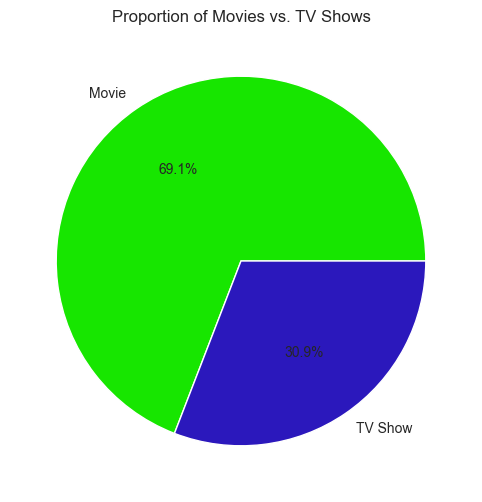

In [20]:
plt.figure(figsize=(8,6))
type_counts = df['type'].value_counts()
plt.pie(type_counts,labels=type_counts.index.astype(str).tolist(),autopct="%1.1f%%",startangle=360,colors=["#17e600", "#2b18bc"])
plt.title('Proportion of Movies vs. TV Shows')
plt.ylabel('')
plt.show()

Insight: The Netflix library is dominated by Movies, which make up roughly 70% of the content in this dataset.

4.2 How has content been added over time?

In [21]:
df.groupby(['year_added','type']).size()

year_added  type   
2008        Movie         1
            TV Show       1
2009        Movie         2
2010        Movie         1
2011        Movie        13
2012        Movie         3
2013        Movie         6
            TV Show       5
2014        Movie        19
            TV Show       6
2015        Movie        58
            TV Show      30
2016        Movie       256
            TV Show     184
2017        Movie       861
            TV Show     361
2018        Movie      1255
            TV Show     429
2019        Movie      1497
            TV Show     656
2020        Movie      1312
            TV Show     697
2021        Movie        88
            TV Show      29
dtype: int64

In [22]:
content_over_time = df.groupby(['year_added','type']).size().unstack()
print(content_over_time)

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      NaN
2010           1.0      NaN
2011          13.0      NaN
2012           3.0      NaN
2013           6.0      5.0
2014          19.0      6.0
2015          58.0     30.0
2016         256.0    184.0
2017         861.0    361.0
2018        1255.0    429.0
2019        1497.0    656.0
2020        1312.0    697.0
2021          88.0     29.0


type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      6.0
2015          58.0     30.0
2016         256.0    184.0
2017         861.0    361.0
2018        1255.0    429.0
2019        1497.0    656.0
2020        1312.0    697.0
2021          88.0     29.0


<Figure size 1000x800 with 0 Axes>

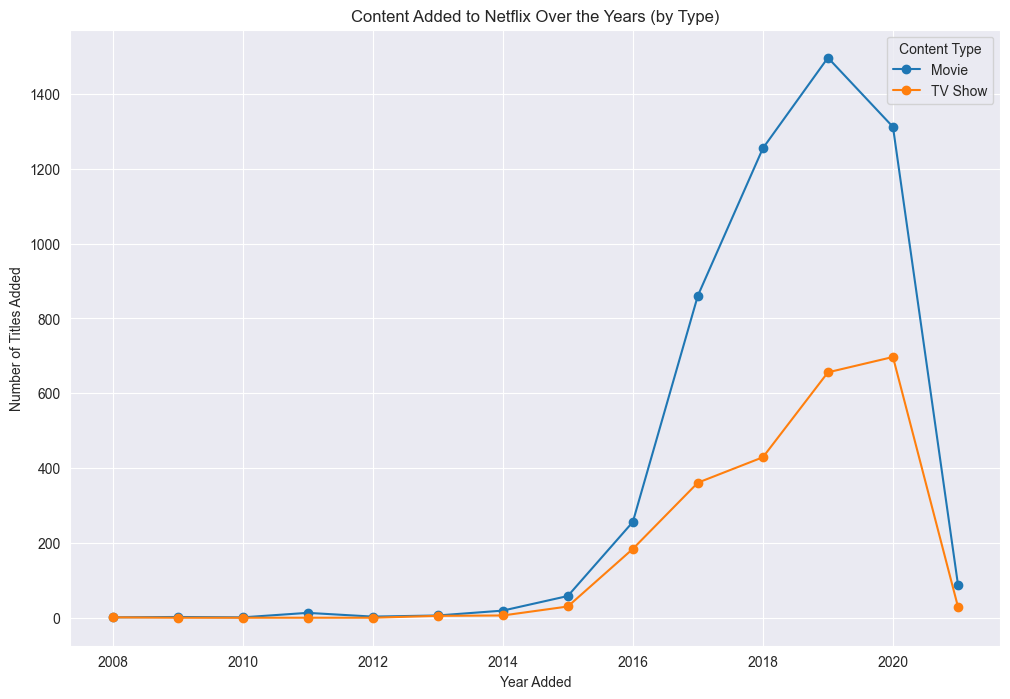

In [23]:
content_over_time = df.groupby(['year_added','type']).size().unstack().fillna(0)
print(content_over_time)
plt.figure(figsize=(10,8))
content_over_time.plot(kind='line',marker='o',figsize=(12,8))
plt.title('Content Added to Netflix Over the Years (by Type)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

Insight : By separating movies and TV shows, we can see that while both grew significantly, the addition of movies accelerated much more dramatically, peaking in 2019. The growth in TV shows has been more steady. There appears to be a slight slowdown in content additions in 2020 and 2021, which could be due to the COVID-19 pandemic affecting productions or the dataset being incomplete for the latest year.

4.3 What are the most popular genres?

Theoretical Concept: Handling Multi-Value Text Columns
The listed_in column contains strings with multiple genres separated by commas (e.g., "Dramas, International Movies"). To analyze each genre individually, we need to transform the data. A common technique is to:

Split the string in each row into a list of genres.
Explode the DataFrame so that each genre in the list gets its own row, duplicating the other information for that title. This allows us to perform a value_counts() on the genres.

In [24]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


In [25]:
df['listed_in']

0       International TV Shows, TV Dramas, TV Sci-Fi &...
1                            Dramas, International Movies
2                     Horror Movies, International Movies
3       Action & Adventure, Independent Movies, Sci-Fi...
4                                                  Dramas
                              ...                        
7782                         Dramas, International Movies
7783       Dramas, International Movies, Music & Musicals
7784    Documentaries, International Movies, Music & M...
7785                   International TV Shows, Reality TV
7786                      Documentaries, Music & Musicals
Name: listed_in, Length: 7770, dtype: object

In [26]:
df['listed_in'].str.split(',').explode()

0       International TV Shows
0                    TV Dramas
0          TV Sci-Fi & Fantasy
1                       Dramas
1         International Movies
                 ...          
7784          Music & Musicals
7785    International TV Shows
7785                Reality TV
7786             Documentaries
7786          Music & Musicals
Name: listed_in, Length: 17042, dtype: object

In [27]:
df['listed_in'].str.split(',')

0       [International TV Shows,  TV Dramas,  TV Sci-F...
1                         [Dramas,  International Movies]
2                  [Horror Movies,  International Movies]
3       [Action & Adventure,  Independent Movies,  Sci...
4                                                [Dramas]
                              ...                        
7782                      [Dramas,  International Movies]
7783    [Dramas,  International Movies,  Music & Music...
7784    [Documentaries,  International Movies,  Music ...
7785                [International TV Shows,  Reality TV]
7786                   [Documentaries,  Music & Musicals]
Name: listed_in, Length: 7770, dtype: object

In [28]:
genres = df.assign(genre = df['listed_in'].str.split(',')).explode('genre')

In [29]:
genres

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre
0,s1,TV Show,3%,unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,International TV Shows
0,s1,TV Show,3%,unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Dramas
0,s1,TV Show,3%,unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Sci-Fi & Fantasy
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,Dramas
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,International Movies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7784,s7785,Movie,Zulu Man in Japan,unknown,Nasty C,United States,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9,Music & Musicals
7785,s7786,TV Show,Zumbo's Just Desserts,unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10,International TV Shows
7785,s7786,TV Show,Zumbo's Just Desserts,unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10,Reality TV
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,unknown,"United Kingdom, Canada, United States",2020-03-01,2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...,2020,3,Documentaries


In [30]:
genres['genre'].value_counts()

genre
 International Movies        2323
Dramas                       1383
Comedies                     1074
Documentaries                 751
 Dramas                       722
                             ... 
Romantic Movies                 3
Spanish-Language TV Shows       2
Sports Movies                   1
TV Sci-Fi & Fantasy             1
LGBTQ Movies                    1
Name: count, Length: 73, dtype: int64

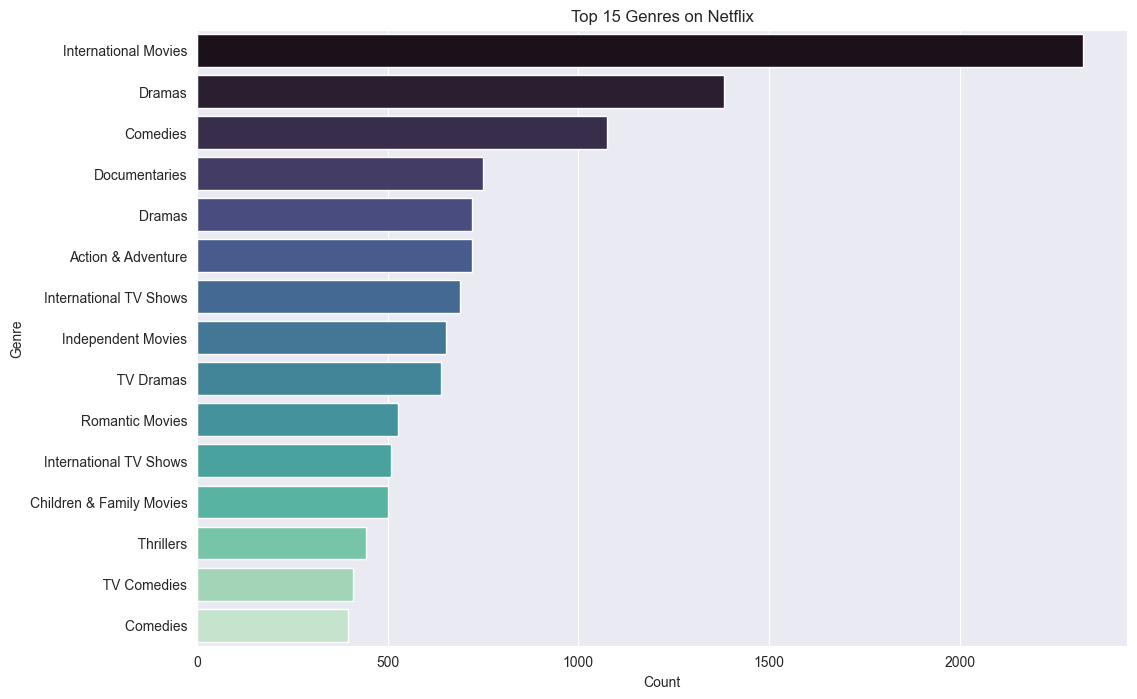

In [31]:
# Get the top 15 genres and their counts
top_genres_counts = genres['genre'].value_counts().reset_index()
top_genres_counts.columns = ['genre', 'count'] # Rename columns for clarity

# Select only the top 15 for plotting
top_genres_counts_plot = top_genres_counts.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(y='genre', x='count', data=top_genres_counts_plot, palette='mako', hue='genre', legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

Insight  : "International Movies"is the most common genre tag,highlighting Netflix's global content stratergy.This followed comedies,Action & Adventure.

4.4 What is the distribution of content duration ? 

In [32]:
# Separate movies and TV shows
movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

In [33]:
movies_df['duration_min'] = movies_df['duration'].str.replace(" min","").astype(int)

In [34]:
tv_shows_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,2017-07-01,2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...,2017,7
11,s12,TV Show,1983,unknown,"Robert Więckiewicz, Maciej Musiał, Michalina O...","Poland, United States",2018-11-30,2018,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Dramas","In this dark alt-history thriller, a naïve law...",2018,11
12,s13,TV Show,1994,Diego Enrique Osorno,unknown,Mexico,2019-05-17,2019,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...",Archival video and new interviews examine Mexi...,2019,5
16,s17,TV Show,Feb-09,unknown,"Shahd El Yaseen, Shaila Sabt, Hala, Hanadi Al-...",United States,2019-03-20,2018,TV-14,1 Season,"International TV Shows, TV Dramas","As a psychology professor faces Alzheimer's, h...",2019,3


In [35]:
tv_shows_df['seasons'] = tv_shows_df['duration'].str.replace(" Seasons","").str.replace(" Season","").astype(int)

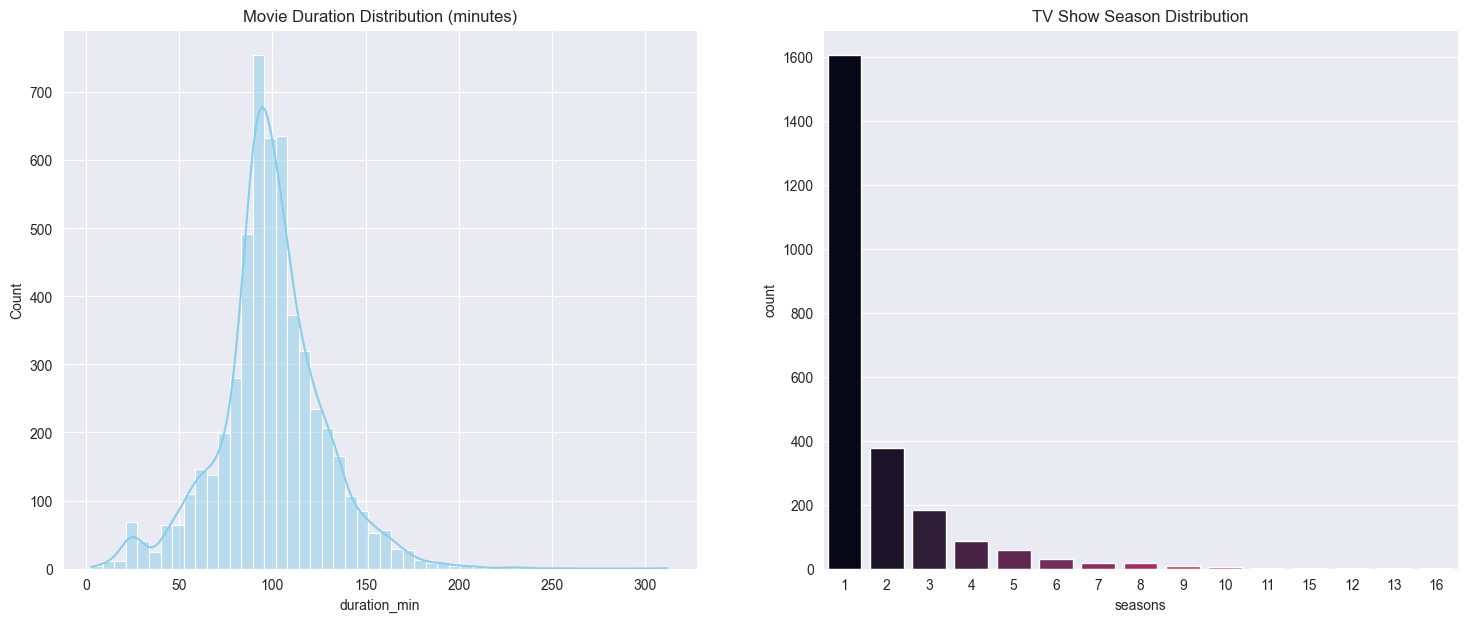

In [36]:
# Plot the distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Movie Duration Distribution
sns.histplot(ax=axes[0], data=movies_df, x='duration_min', bins=50, kde=True, color='skyblue').set_title('Movie Duration Distribution (minutes)')

# TV Show Season Distribution
sns.countplot(ax=axes[1], x='seasons', data=tv_shows_df, palette='rocket', order=tv_shows_df['seasons'].value_counts().index, hue='seasons', legend=False).set_title('TV Show Season Distribution')

plt.show()

Insight:

The majority of movies on Netflix are between 80 and 120 minutes long, which is standard for feature films.
The vast majority of TV shows on Netflix are short-lived, with most having only 1 season. This could reflect a strategy of producing many pilots and only renewing the most successful ones, or a focus on limited series.

4.5 Where does the content come from? (Geographical Analysis)

In [37]:
# Handle the multi-country listings similar to genres
countries = df.assign(country=df['country'].str.split(', ')).explode('country')

In [38]:
# Get the top 15 countries and their counts
top_countries_counts = countries['country'].value_counts().reset_index()
top_countries_counts.columns = ['country', 'count'] # Rename columns for clarity

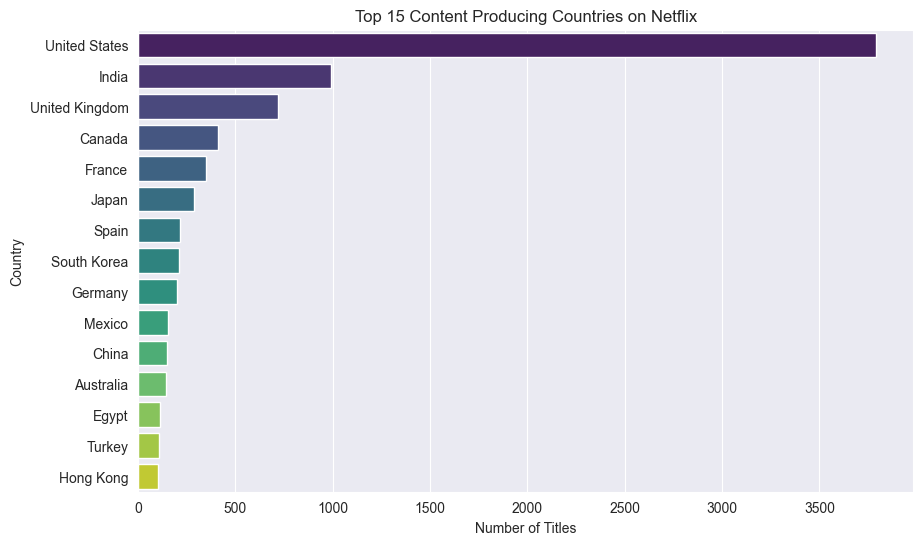

In [39]:
# Select only the top 15 for plotting
top_countries_counts_plot = top_countries_counts.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(y='country', x='count', data=top_countries_counts_plot, palette='viridis', hue='country', legend=False)
plt.title('Top 15 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

Insight: The United States is by far the largest producer of content available on Netflix. However, India is a very strong second, which explains why so many of the top actors were from India. The UK, Japan, and South Korea also represent major content markets for the platform, emphasizing its global nature.

4.6 What are the maturity ratings of the content?

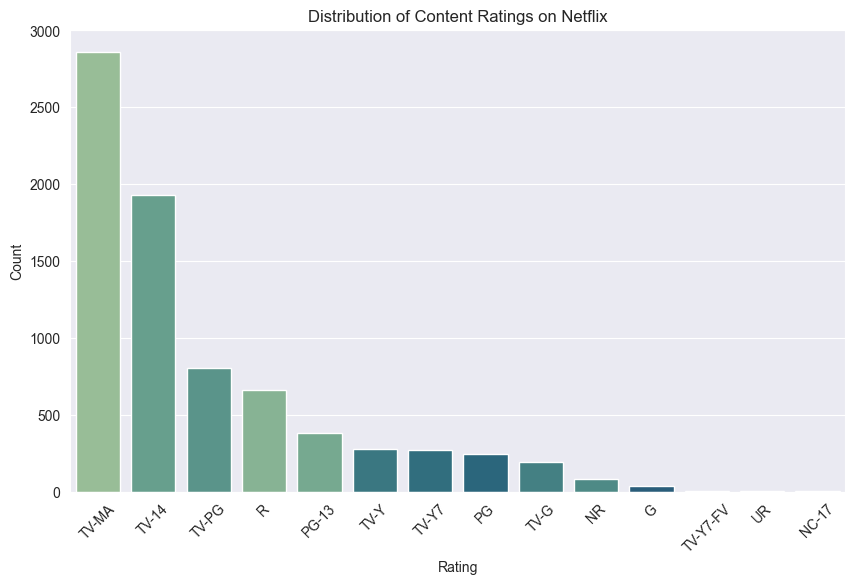

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='crest', hue='rating', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Insight: A large portion of Netflix's content is aimed at mature audiences, with TV-MA (Mature Audience) and TV-14 (Parents Strongly Cautioned) being the two most common ratings. This suggests a focus on adult viewers over content for children (TV-G, TV-Y).

Step 5: Feature Engineering - Content Freshness
Let's create a new feature to analyze how old content is when it gets added to Netflix. This can tell us about their acquisition strategy (buying old classics vs. releasing new originals).

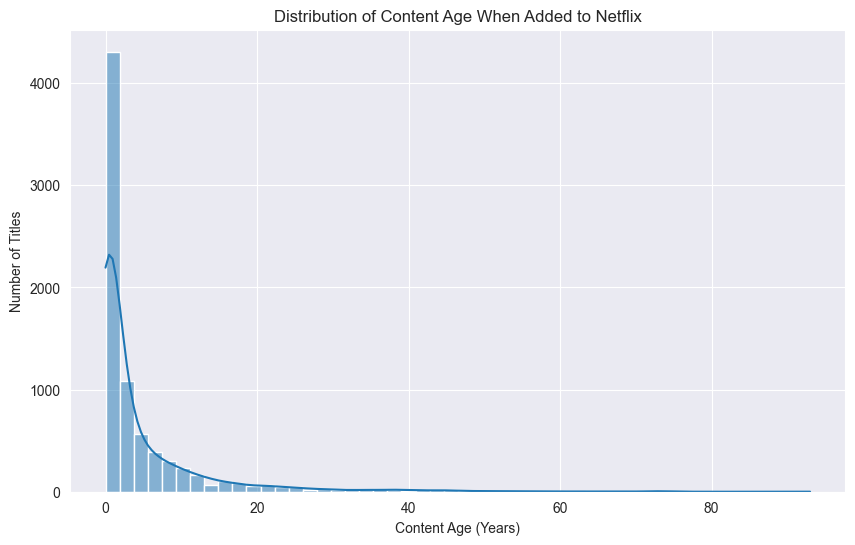

In [41]:
## Create 'age_on_netflix' feature
df['age_on_netflix'] = df['year_added'] - df['release_year']

content_age = df[df['age_on_netflix'] >= 0]

plt.figure(figsize=(10, 6))
sns.histplot(data=content_age, x='age_on_netflix', bins=50, kde=True)
plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

Insight: The large spike at 0 indicates that a significant amount of content is added in the same year it's released, which is characteristic of "Netflix Originals." However, there is a very long tail, showing that Netflix also heavily invests in acquiring licensed content that can be decades old, building a deep library of classic films and shows.

Step 6: Deeper Multivariate Analysis

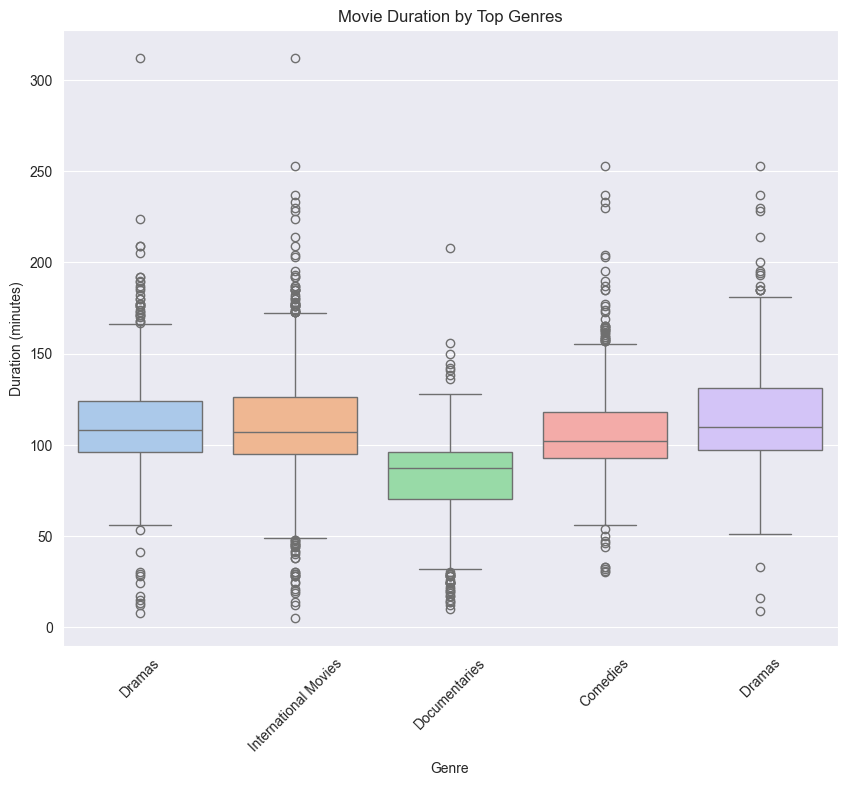

In [42]:
# Analyze movie duration across different top genres
top_genres = genres['genre'].value_counts().index[:5]
genres_movies = genres[(genres['type'] == 'Movie') & (genres['genre'].isin(top_genres))].copy()
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(10, 8))
sns.boxplot(data=genres_movies, x='genre', y='duration_min', palette='pastel', hue='genre', legend=False)
plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()

Insight: While the median duration for most top genres is similar (around 90-100 minutes), we can see some interesting variations. For example, Dramas tend to have a wider range of durations, with many longer films. International Movies also show a broad distribution, reflecting diverse filmmaking styles from around the world.

Step 7: Word Cloud from Content Descriptions
As a final visual analysis, let's generate a word cloud from the description column to see what themes and words are most common in Netflix content.

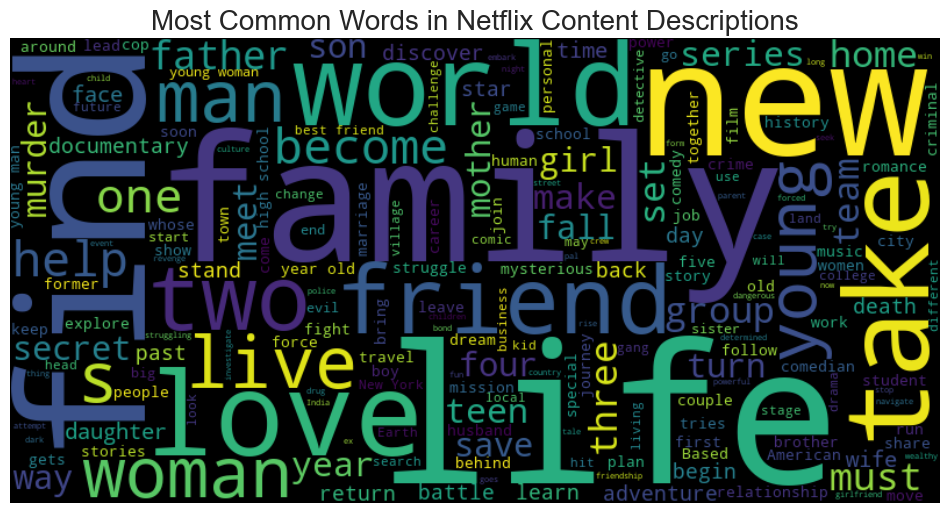

In [43]:
# Combine all descriptions into a single string
text = ' '.join(df['description'])

# Create and generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

# Display the generated image
plt.figure(figsize=(12, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20)
plt.show()

Insight: The word cloud highlights common themes and subjects. Words like "life," "family," "love," "young," "friends," and "world" are prominent, suggesting that much of the content revolves around human relationships and personal journeys. Action-oriented words like "find," "secret," and "new" also appear frequently.

4.7 How has the distribution of content ratings changed over time?

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         7770 non-null   object        
 1   type            7770 non-null   object        
 2   title           7770 non-null   object        
 3   director        7770 non-null   object        
 4   cast            7770 non-null   object        
 5   country         7770 non-null   object        
 6   date_added      7770 non-null   datetime64[ns]
 7   release_year    7770 non-null   int64         
 8   rating          7770 non-null   object        
 9   duration        7770 non-null   object        
 10  listed_in       7770 non-null   object        
 11  description     7770 non-null   object        
 12  year_added      7770 non-null   int32         
 13  month_added     7770 non-null   int32         
 14  age_on_netflix  7770 non-null   int64         
dtypes: dateti

In [45]:
df['rating']

0       TV-MA
1       TV-MA
2           R
3       PG-13
4       PG-13
        ...  
7782    TV-MA
7783    TV-14
7784    TV-MA
7785    TV-PG
7786    TV-MA
Name: rating, Length: 7770, dtype: object

In [46]:
rate = df['rating'].value_counts().index
print(rate)
gr = df.groupby(['rating', 'date_added']).size().unstack()
gr.fillna(0)


Index(['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'TV-Y', 'TV-Y7', 'PG', 'TV-G',
       'NR', 'G', 'TV-Y7-FV', 'UR', 'NC-17'],
      dtype='object', name='rating')


date_added,2008-01-01,2008-02-04,2009-05-05,2009-11-18,2010-11-01,2011-05-17,2011-09-27,2011-10-01,2012-02-21,2012-11-14,...,2021-01-06,2021-01-07,2021-01-08,2021-01-10,2021-01-11,2021-01-12,2021-01-13,2021-01-14,2021-01-15,2021-01-16
rating,,,,,,,,,,,,,,,,,,,,,
G,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NC-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NR,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0
PG-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
R,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,2.0,1.0
TV-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,1.0,1.0,5.0,2.0,0.0,0.0,0.0,1.0,2.0,1.0
TV-G,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
TV-MA,1.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,...,2.0,0.0,5.0,3.0,1.0,3.0,1.0,1.0,4.0,0.0


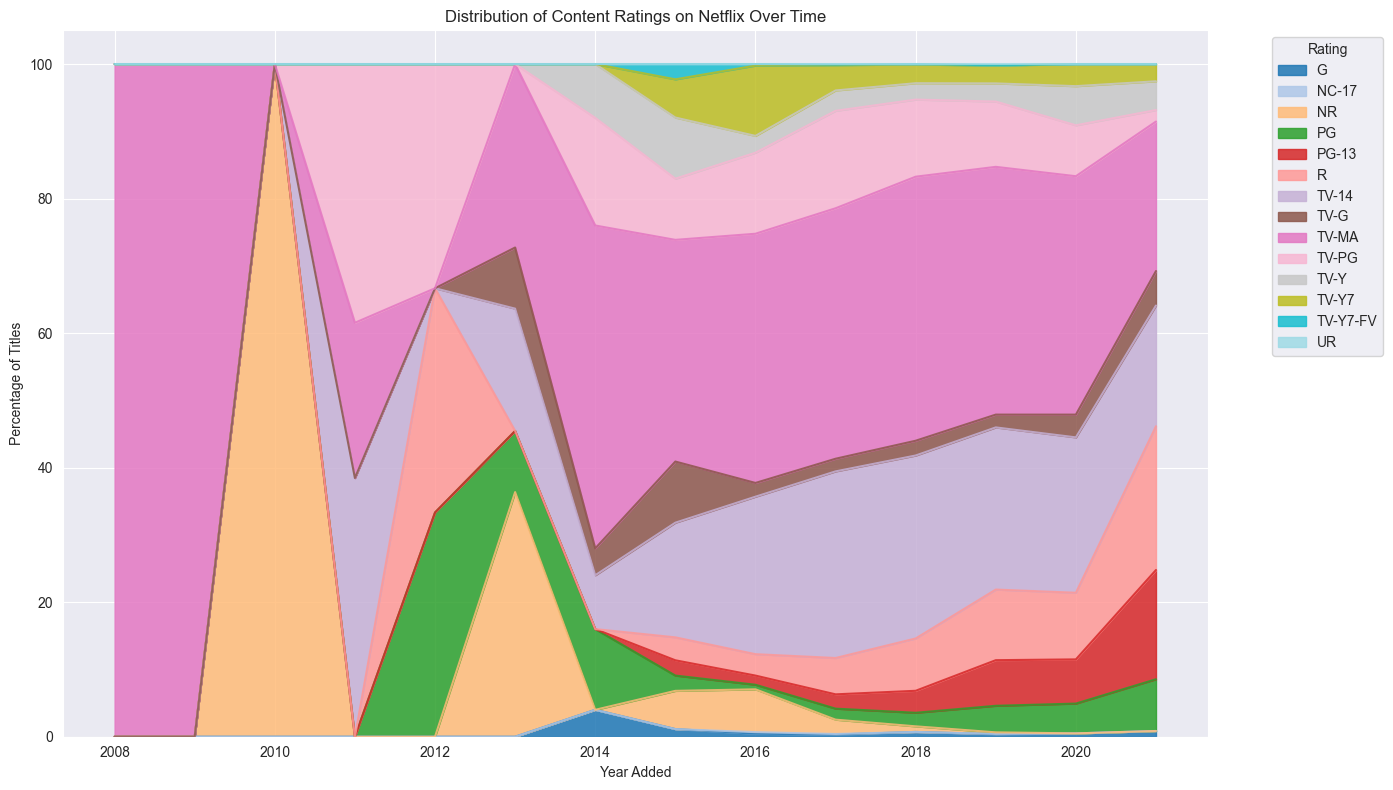

In [47]:
# Analyze how the distribution of content ratings has changed over time
rating_year = df.groupby(['year_added', 'rating']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 8))
rating_year_pct = rating_year.div(rating_year.sum(axis=1), axis=0) * 100  # Convert to percentage for better comparison
rating_year_pct.plot(kind='area', stacked=True, colormap='tab20', alpha=0.85, ax=plt.gca())
plt.title('Distribution of Content Ratings on Netflix Over Time')
plt.xlabel('Year Added')
plt.ylabel('Percentage of Titles')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

4.8 Is there a relationship between content age and its type (Movie vs. TV Show)?

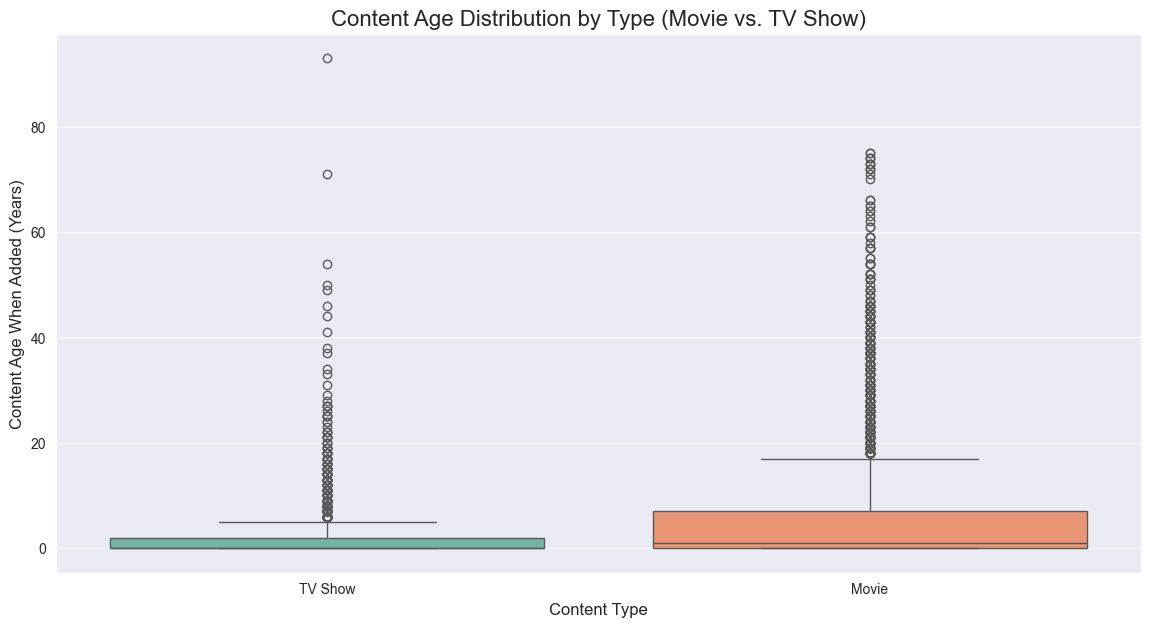


Statistical Summary of Content Age by Type:

          count      mean       std  min  25%  50%  75%   max
type                                                         
Movie    5370.0  5.565736  9.729067  0.0  0.0  1.0  7.0  75.0
TV Show  2388.0  2.326214  5.287340  0.0  0.0  0.0  2.0  93.0


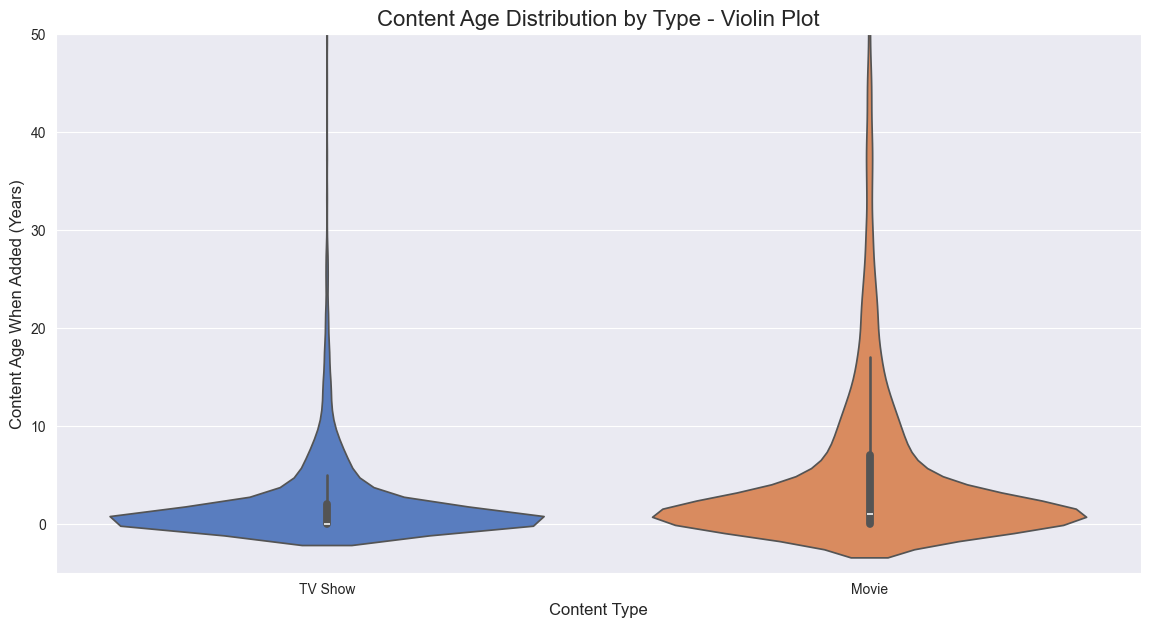

In [48]:
# Compare content age distribution between Movies and TV Shows
content_age_valid = df[df['age_on_netflix'] >= 0]

plt.figure(figsize=(14, 7))

# Create box plot to compare distributions
sns.boxplot(x='type', y='age_on_netflix', data=content_age_valid, palette='Set2', hue='type', legend=False)
plt.title('Content Age Distribution by Type (Movie vs. TV Show)', fontsize=16)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Content Age When Added (Years)', fontsize=12)
plt.show()

# Display statistical summary
print("\nStatistical Summary of Content Age by Type:\n")
print(content_age_valid.groupby('type')['age_on_netflix'].describe())

# Create violin plot for more detailed distribution view
plt.figure(figsize=(14, 7))
sns.violinplot(x='type', y='age_on_netflix', data=content_age_valid, palette='muted', hue='type', legend=False)
plt.title('Content Age Distribution by Type - Violin Plot', fontsize=16)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Content Age When Added (Years)', fontsize=12)
plt.ylim(-5, 50)  # Limit y-axis for better visibility
plt.show()

**Insight**: There is a clear relationship between content age and type:

- **Movies** tend to be older when added to Netflix, with a higher median age and more content that is several years or decades old. This suggests Netflix acquires a significant library of older films.
- **TV Shows** are typically much fresher, with most being added within a few years of their release. The lower median age indicates Netflix focuses more on recent TV content, possibly because TV shows lose relevance faster than classic movies.
- Both types have a concentration of content added in the same year as release (age = 0), representing Netflix Originals, but this is more pronounced for TV Shows.

4.9 Can we identify any trends in content production based on the release year vs. the year added to Netflix?

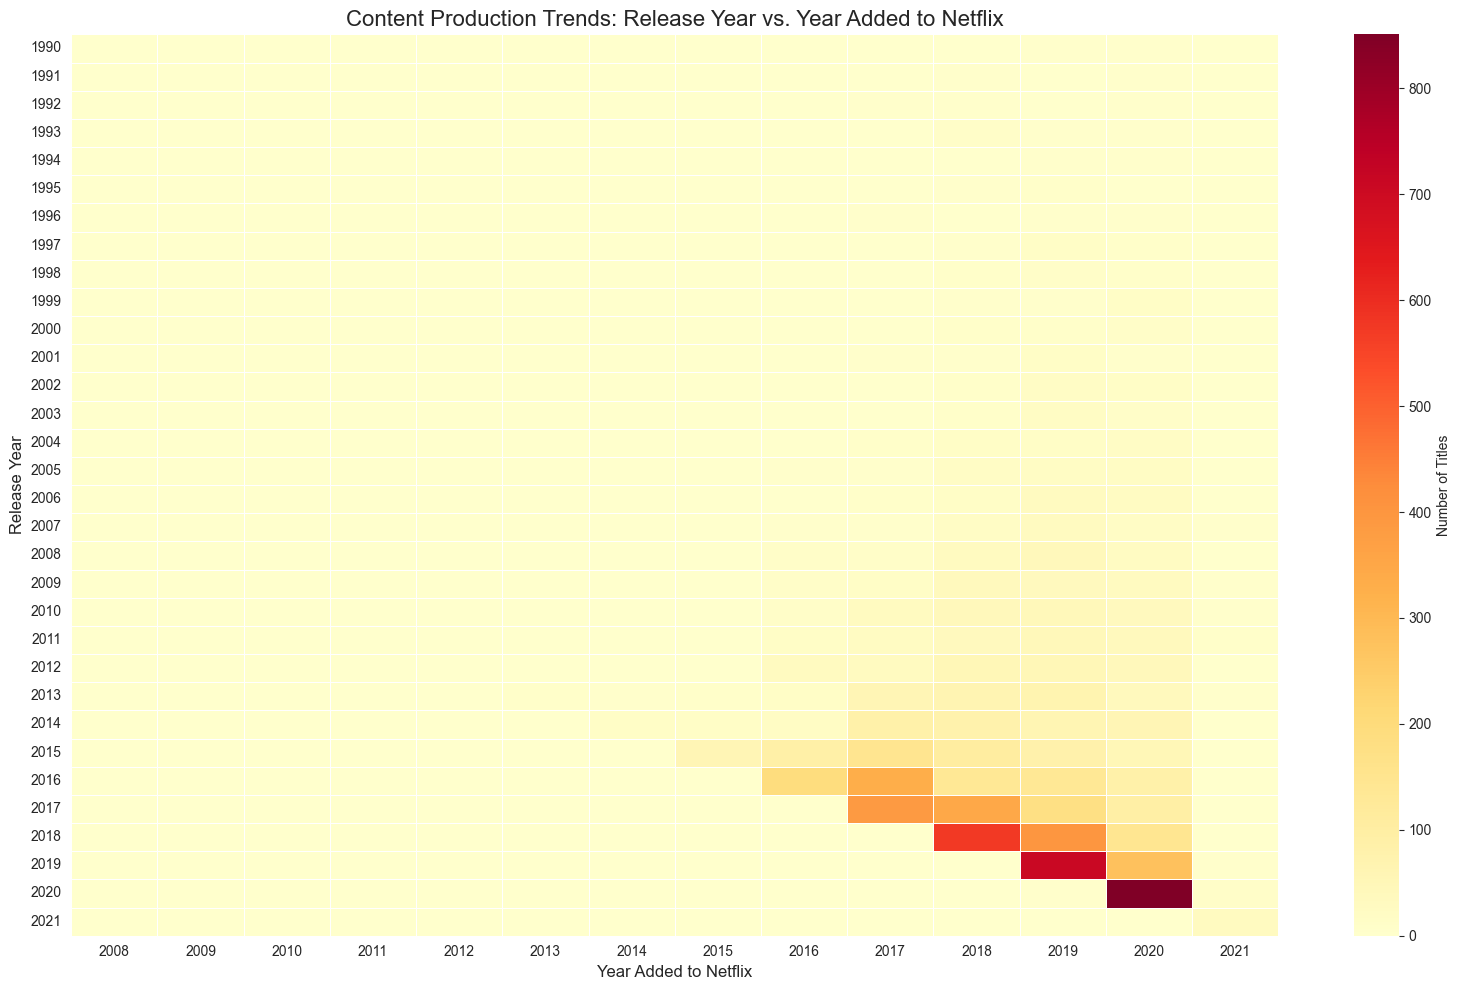

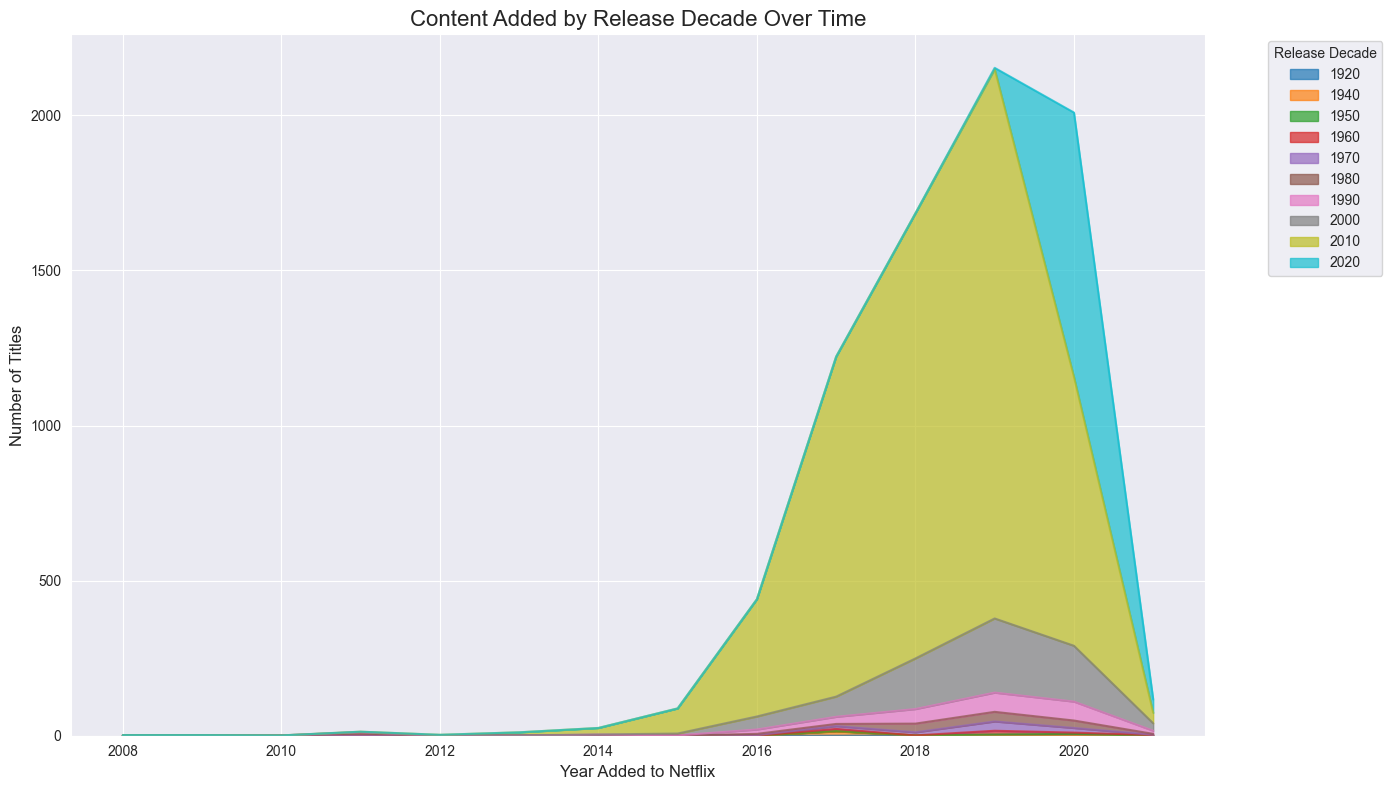

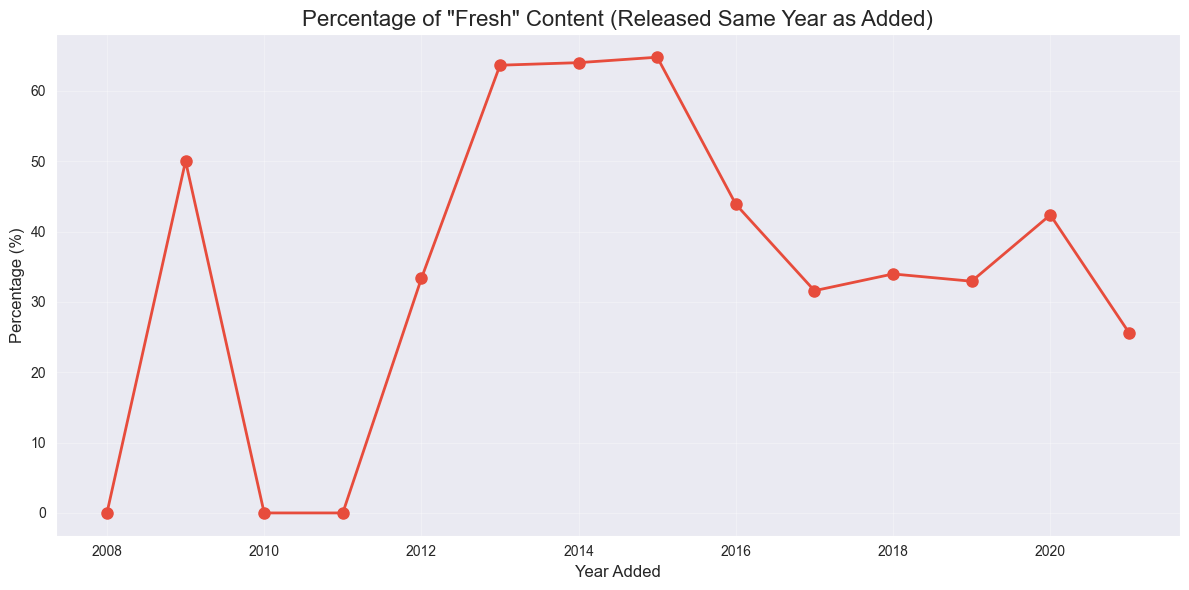


Key Statistics:
Average percentage of fresh content: 34.72%

Top 5 years with most fresh content:
year_added
2015    64.772727
2014    64.000000
2013    63.636364
2009    50.000000
2016    43.863636
dtype: float64


In [49]:
# Create a heatmap to visualize release year vs year added patterns
pivot_data = df.groupby(['release_year', 'year_added']).size().reset_index(name='count')
pivot_table = pivot_data.pivot(index='release_year', columns='year_added', values='count').fillna(0)

# Filter to focus on recent years for better visualization
pivot_table_filtered = pivot_table.loc[1990:, 2008:]

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_table_filtered, cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Number of Titles'})
plt.title('Content Production Trends: Release Year vs. Year Added to Netflix', fontsize=16)
plt.xlabel('Year Added to Netflix', fontsize=12)
plt.ylabel('Release Year', fontsize=12)
plt.tight_layout()
plt.show()

# Analyze content by release decade
df['release_decade'] = (df['release_year'] // 10) * 10
decade_year_added = df.groupby(['release_decade', 'year_added']).size().unstack(fill_value=0)

# Plot stacked area chart for decade trends
plt.figure(figsize=(14, 8))
decade_year_added.T.plot(kind='area', stacked=True, alpha=0.7, colormap='tab10', ax=plt.gca())
plt.title('Content Added by Release Decade Over Time', fontsize=16)
plt.xlabel('Year Added to Netflix', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.legend(title='Release Decade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Calculate the proportion of "fresh" content (released in same year as added)
fresh_content = df[df['age_on_netflix'] == 0].groupby('year_added').size()
total_content = df.groupby('year_added').size()
fresh_percentage = (fresh_content / total_content * 100).fillna(0)

plt.figure(figsize=(12, 6))
plt.plot(fresh_percentage.index, fresh_percentage.values, marker='o', linewidth=2, markersize=8, color='#e74c3c')
plt.title('Percentage of "Fresh" Content (Released Same Year as Added)', fontsize=16)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey Statistics:")
print(f"Average percentage of fresh content: {fresh_percentage.mean():.2f}%")
print(f"\nTop 5 years with most fresh content:")
print(fresh_percentage.nlargest(5))

5.0 What are the most common word pairs or phrases in content descriptions?

**Insight**: The most common word pairs and phrases reveal recurring narrative patterns in Netflix content:

- **Common themes** include phrases like "young man," "high school," "new life," and "his life," indicating a focus on coming-of-age stories and personal transformation.
- **Relationship-focused** phrases such as "falls in love," "her family," and "his family" highlight the importance of interpersonal relationships in Netflix's content.
- **Action/conflict** phrases like "must fight," "must find," and "sets out" suggest many stories revolve around quests, challenges, and conflicts that characters must overcome.
- The prevalence of phrases like "a young," "in the," and "to the" shows common grammatical structures, but the more meaningful phrases reveal Netflix's emphasis on character-driven narratives with elements of struggle, love, and personal growth.

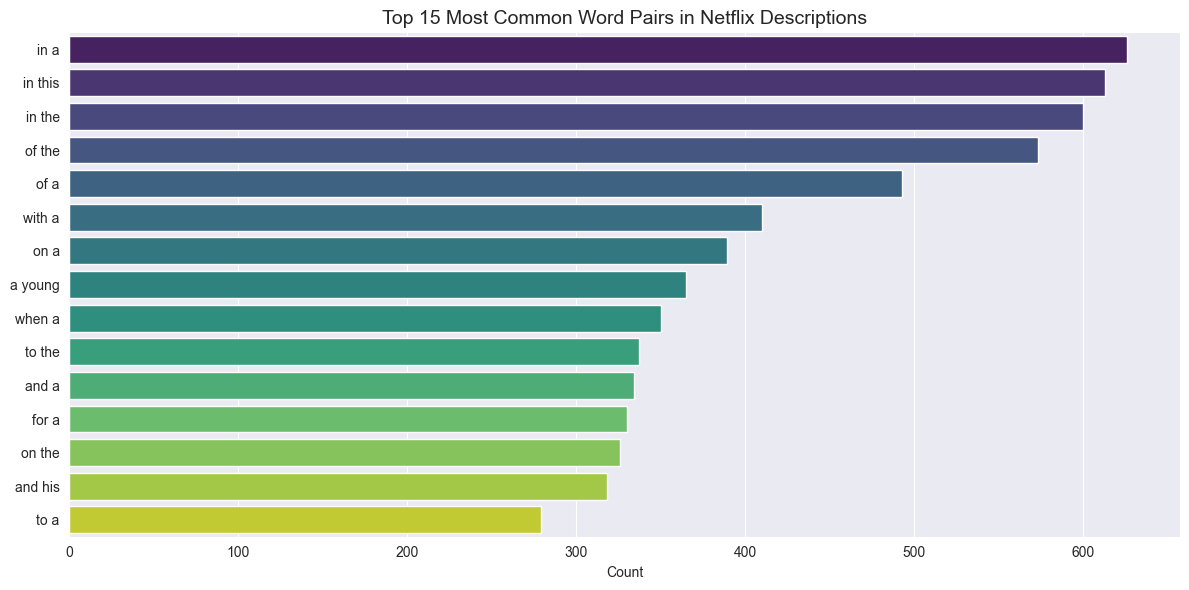

Most Common Word Pairs:
in a: 626
in this: 613
in the: 600
of the: 573
of a: 493
with a: 410
on a: 389
a young: 365
when a: 350
to the: 337
and a: 334
for a: 330
on the: 326
and his: 318
to a: 279


In [50]:
from collections import Counter

# Combine all descriptions into one text
all_text = ' '.join(df['description'].astype(str).str.lower())

# Split into words and create word pairs
words = all_text.split()
word_pairs = [f"{words[i]} {words[i+1]}" for i in range(len(words)-1)]

# Count and get top 15 word pairs
pair_counts = Counter(word_pairs).most_common(15)
pairs_df = pd.DataFrame(pair_counts, columns=['Word Pair', 'Count'])

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(y='Word Pair', x='Count', data=pairs_df, palette='viridis', hue='Word Pair', legend=False)
plt.title('Top 15 Most Common Word Pairs in Netflix Descriptions', fontsize=14)
plt.xlabel('Count')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Print the results
print("Most Common Word Pairs:")
for pair, count in pair_counts:
    print(f"{pair}: {count}")

5.1 Who are the top directors on Netflix?

In [ ]:
print(df['director'])

0                 unknown
1       Jorge Michel Grau
2            Gilbert Chan
3             Shane Acker
4          Robert Luketic
              ...        
7782          Josef Fares
7783          Mozez Singh
7784              unknown
7785              unknown
7786             Sam Dunn
Name: director, Length: 7770, dtype: object


: 

In [51]:
directors = df[df['director'] != 'unknown'].assign(director=df['director'].str.split(', ')).explode('director')

# Get top 15 directors
top_directors = directors['director'].value_counts().head(15)
print(top_directors)
print(directors)

director
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Youssef Chahine        12
Jay Chapman            12
Steven Spielberg       10
Anurag Kashyap          9
Shannon Hartman         9
David Dhawan            9
Kunle Afolayan          8
Quentin Tarantino       8
Lance Bangs             8
Name: count, dtype: int64
     show_id     type                                    title  \
1         s2    Movie                                     7:19   
2         s3    Movie                                    23:59   
3         s4    Movie                                        9   
4         s5    Movie                                       21   
5         s6  TV Show                                       46   
...      ...      ...                                      ...   
7780   s7781    Movie                                      Zoo   
7781   s7782    Movie                          

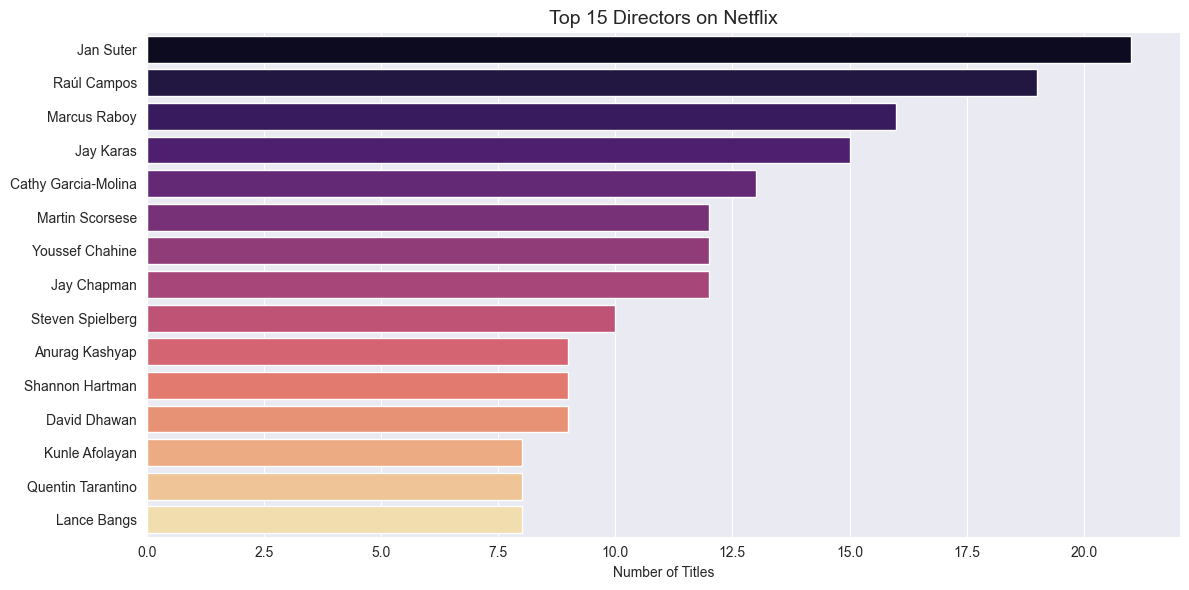

Total unique directors: 4476

Top 10 Directors:
1. Jan Suter: 21 titles
2. Raúl Campos: 19 titles
3. Marcus Raboy: 16 titles
4. Jay Karas: 15 titles
5. Cathy Garcia-Molina: 13 titles
6. Martin Scorsese: 12 titles
7. Youssef Chahine: 12 titles
8. Jay Chapman: 12 titles
9. Steven Spielberg: 10 titles
10. Anurag Kashyap: 9 titles


In [52]:
# Split directors (some titles have multiple directors)
directors = df[df['director'] != 'unknown'].assign(director=df['director'].str.split(', ')).explode('director')

# Get top 15 directors
top_directors = directors['director'].value_counts().head(15)

# Create DataFrame for visualization
directors_df = pd.DataFrame({'Director': top_directors.index, 'Count': top_directors.values})

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(y='Director', x='Count', data=directors_df, palette='magma', hue='Director', legend=False)
plt.title('Top 15 Directors on Netflix', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Total unique directors: {directors['director'].nunique()}")
print(f"\nTop 10 Directors:")
for i, (director, count) in enumerate(top_directors.head(10).items(), 1):
    print(f"{i}. {director}: {count} titles")

**Insight**: The director analysis reveals interesting patterns:

- The top directors have a strong presence with multiple titles, indicating Netflix's strategy of working repeatedly with prolific filmmakers
- Many of the top directors likely specialize in documentary series or international content, which aligns with Netflix's global expansion strategy
- The diversity in the list reflects Netflix's commitment to varied content from different regions and genres